In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('used_cars.csv')

In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


* **brand**: Aracın markası (Örn: Ford, BMW, Toyota)
* **model**: Aracın modeli (Örn: F-150, Camry)
* **model_year**: Aracın üretim/model yılı (Örn: 2018, 2021)
* **milage**: Aracın kat ettiği mesafe / kilometre bilgisi
* **fuel_type**: Yakıt türü (Örn: Gasoline, Hybrid, Diesel)
* **engine**: Motor hacmi ve teknik özellikleri
* **transmission**: Vites türü (Örn: Automatic, Manual)
* **ext_col**: Dış renk (Exterior color)
* **int_col**: İç renk (Interior color)
* **accident**: Kazaya karışıp karışmadığı / Hasar durumu
* **clean_title**: Aracın hasarsız/temiz tapuya sahip olup olmadığı
* **price**: Aracın satış fiyatı (Hedef/Target değişken)

In [5]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [6]:
df['model_year'].value_counts()

model_year
2022    354
2021    350
2020    322
2018    315
2019    297
2016    268
2017    259
2015    228
2023    226
2014    181
2013    158
2012    141
2011    124
2008    113
2010    100
2007     98
2005     72
2009     72
2006     66
2004     60
2003     49
2001     34
2002     32
2000     17
1999     15
1998     11
1993      9
1997      9
1996      8
1994      7
2024      6
1995      6
1992      1
1974      1
Name: count, dtype: int64

In [7]:
df['milage'].value_counts()

milage
110,000 mi.    16
45,000 mi.     15
55,000 mi.     13
120,000 mi.    13
40,000 mi.     12
               ..
81,880 mi.      1
52,750 mi.      1
300,183 mi.     1
35,035 mi.      1
34,742 mi.      1
Name: count, Length: 2818, dtype: int64

In [8]:
# buradaki mi,virgul ve bosluklari silerek floata cevirmek istiyorum kolonumu

In [9]:
df['milage'] = df['milage'].str.replace('mi','',regex=False).str.strip()

In [10]:
df['milage'] = df['milage'].str.replace(',','',regex=False)

In [11]:
df['milage'] = df['milage'].str.strip(' .').astype(float)

In [12]:
df['milage'] = df['milage'].astype(float)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 376.0+ KB


-- dan 45 ve not supported den 2 tane var toplamda 47 vermiz kayip yada yok 47 tane vri cok bir alan kaplamadigi icin bunlari silecegim 

In [14]:
df['fuel_type'].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

kolonumuzda -- ve not supported kismini kladiridim cunku eda ve feature enginering de sikinti yartmasimasi icin

In [15]:
# İçinde '-' geçen veya uzunluğu 2 karakterden kısa olan (yani tek başına işaret/boşluk kalan) ne varsa filtrele
df = df[~df['fuel_type'].astype(str).str.contains('-', regex=False)]
df = df[df['fuel_type'].astype(str).str.strip().str.len() > 2]

# Kontrol edelim
print(df['fuel_type'].value_counts())
print("Kalan toplam satır:", len(df))

fuel_type
Gasoline         3309
Hybrid            194
E85 Flex Fuel     139
Diesel            116
not supported       2
Name: count, dtype: int64
Kalan toplam satır: 3930


In [16]:
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel',
       'not supported'], dtype=object)

degerlermiz string oldugu icin ve aralarinda iyilik kotuluk anlamda bir siralma olmadigi icin one hot encoding yapmayi uygun goruyorum verimde 

In [17]:
df = pd.get_dummies(df,columns=['fuel_type'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   brand                    3930 non-null   object 
 1   model                    3930 non-null   object 
 2   model_year               3930 non-null   int64  
 3   milage                   3930 non-null   float64
 4   engine                   3930 non-null   object 
 5   transmission             3930 non-null   object 
 6   ext_col                  3930 non-null   object 
 7   int_col                  3930 non-null   object 
 8   accident                 3819 non-null   object 
 9   clean_title              3336 non-null   object 
 10  price                    3930 non-null   object 
 11  fuel_type_Diesel         3930 non-null   bool   
 12  fuel_type_E85 Flex Fuel  3930 non-null   bool   
 13  fuel_type_Gasoline       3930 non-null   bool   
 14  fuel_type_Hybrid         3930

In [19]:
df['engine'].value_counts()

engine
2.0L I4 16V GDI DOHC Turbo                                         52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel                       48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel                       47
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel              44
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel                       42
                                                                   ..
282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel                        1
2L I-4 gasoline direct injection, DOHC, variable valve control,     1
150.0HP 3.8L V6 Cylinder Engine Gasoline Fuel                       1
715.0HP 5.2L 12 Cylinder Engine Gasoline Fuel                       1
2.0 Liter Supercharged                                              1
Name: count, Length: 1124, dtype: int64

In [20]:
hp_listesi = []
for metin in df['engine']: # metin bosluklarina gore kelimeleri boldum
    kelimeler = str(metin).split()
    bulunan_hp = None
    
    for kelime in kelimeler:  # icinde hp gecen kelimleri buldum 
        if 'HP' in kelime:
            sayi_metni = kelime.replace('HP', '') # hp kismini sildim ve sadece sayi kismini aldim 
            bulunan_hp = float(sayi_metni)
            break
            
    
    hp_listesi.append(bulunan_hp) # bos olanlari buraya koydum

df['engine_hp'] = hp_listesi
print(df[['engine', 'engine_hp']].head(10))

                                              engine  engine_hp
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...      300.0
1                               3.8L V6 24V GDI DOHC        NaN
2                                     3.5 Liter DOHC        NaN
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...      354.0
4                         2.0L I4 16V GDI DOHC Turbo        NaN
5                                          2.4 Liter        NaN
6       292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel      292.0
7       282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel      282.0
8      311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel      311.0
9        534.0HP Electric Motor Electric Fuel System      534.0


In [21]:
len(df)

3930

In [22]:
df['engine_hp'].notna().sum()

np.int64(3167)

In [23]:
df['engine_hp'].isna().sum()

np.int64(763)

verimizde motorlarin bazilarinda degerler hp olarak verilmis bazilarinda litre olarak verilmis bundan dolayida simdide bir tanede litre kolonu acip datamda Nan veri birakmak istemiyoru

In [24]:
litre_listesi = []

for metin in df['engine']:
    kelimeler = str(metin).split()
    bulunan_litre = None
    
    for kelime in kelimeler:
        if 'L' in kelime and kelime != 'L':  
            temiz_kelime = kelime.replace('L', '').replace('liter', '').replace('Liter', '')
            try:
                bulunan_litre = float(temiz_kelime)
                break
            except ValueError:
                pass
                
    litre_listesi.append(bulunan_litre)

df['engine_liters'] = litre_listesi

In [25]:
df['engine_liters'].notna().sum()

np.int64(3598)

In [26]:
df['engine_liters'].isna().sum()

np.int64(332)

In [27]:
df[['engine','engine_hp','engine_liters']]

,engine,engine_hp,engine_liters
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0,3.7
1,3.8L V6 24V GDI DOHC,NaN,3.8
2,3.5 Liter DOHC,NaN,NaN
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0,3.5
4,2.0L I4 16V GDI DOHC Turbo,NaN,2.0
...,...,...,...
4004,6.0L W12 48V PDI DOHC Twin Turbo,NaN,6.0
4005,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,349.0,3.0
4006,Electric,NaN,NaN
4007,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,450.0,3.5


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   brand                    3930 non-null   object 
 1   model                    3930 non-null   object 
 2   model_year               3930 non-null   int64  
 3   milage                   3930 non-null   float64
 4   engine                   3930 non-null   object 
 5   transmission             3930 non-null   object 
 6   ext_col                  3930 non-null   object 
 7   int_col                  3930 non-null   object 
 8   accident                 3819 non-null   object 
 9   clean_title              3336 non-null   object 
 10  price                    3930 non-null   object 
 11  fuel_type_Diesel         3930 non-null   bool   
 12  fuel_type_E85 Flex Fuel  3930 non-null   bool   
 13  fuel_type_Gasoline       3930 non-null   bool   
 14  fuel_type_Hybrid         3930

In [29]:
df = df.drop(columns=['engine'],axis=1)

engine kismini zaten 2 ayirdim ve isime yarayan kismi aldigim icin bu kolanla isim kalmadi bundan dolayi orayi drop ediyorum

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   brand                    3930 non-null   object 
 1   model                    3930 non-null   object 
 2   model_year               3930 non-null   int64  
 3   milage                   3930 non-null   float64
 4   transmission             3930 non-null   object 
 5   ext_col                  3930 non-null   object 
 6   int_col                  3930 non-null   object 
 7   accident                 3819 non-null   object 
 8   clean_title              3336 non-null   object 
 9   price                    3930 non-null   object 
 10  fuel_type_Diesel         3930 non-null   bool   
 11  fuel_type_E85 Flex Fuel  3930 non-null   bool   
 12  fuel_type_Gasoline       3930 non-null   bool   
 13  fuel_type_Hybrid         3930 non-null   bool   
 14  fuel_type_not supported  3930

In [31]:
df['transmission'].value_counts()

transmission
A/T                                  1006
8-Speed A/T                           395
Transmission w/Dual Shift Mode        387
6-Speed A/T                           360
6-Speed M/T                           243
                                     ... 
10-Speed Automatic with Overdrive       1
9-Speed Automatic with Auto-Shift       1
SCHEDULED FOR OR IN PRODUCTION          1
6 Speed Mt                              1
8-Speed Manual                          1
Name: count, Length: 62, dtype: int64

bu datamizda cok kirli duruyor en mantiklisi burada otomatik ve manuel seklinde verimizi ayrikmak olmali 

In [32]:
trans = df['transmission'].astype(str).str.lower() # once kucuk harfe cevirme yaptimv verimde cunku herseyi yakalmaya calisiyorum
vites_listesi = []
for val in trans:
    if 'a/t' in val or 'automatic' in val or 'auto' in val:
        vites_listesi.append('Automatic')
    elif 'm/t' in val or 'manual' in val or 'mt' in val:
        vites_listesi.append('Manual')
    else:
        vites_listesi.append(None) # Uymayanlar boş kalsın

df['transmission_clean'] = vites_listesi
print(df['transmission_clean'].value_counts(dropna=False))

transmission_clean
Automatic    3098
None          469
Manual        363
Name: count, dtype: int64


none kisimlari silmek biraz sacma olur cunku birazda olsa var bundan dolayi ben burayi doldurmayi tercih edicem 

In [33]:
doldurma = df['transmission_clean'].mode()[0]

In [34]:
df['transmission_clean'] = df['transmission_clean'].fillna(doldurma)

In [35]:
df['transmission_clean'].value_counts()

transmission_clean
Automatic    3567
Manual        363
Name: count, dtype: int64

buraya one hot encoding yapicam datamda

In [36]:
df = pd.get_dummies(df,columns=['transmission_clean'])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   transmission                  3930 non-null   object 
 5   ext_col                       3930 non-null   object 
 6   int_col                       3930 non-null   object 
 7   accident                      3819 non-null   object 
 8   clean_title                   3336 non-null   object 
 9   price                         3930 non-null   object 
 10  fuel_type_Diesel              3930 non-null   bool   
 11  fuel_type_E85 Flex Fuel       3930 non-null   bool   
 12  fuel_type_Gasoline            3930 non-null   bool   
 13  fuel_typ

artik transmission verisiylede alakamiz kalmadigi icin onuda silicem verimden

In [38]:
df = df.drop(columns=['transmission'],axis=1)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   ext_col                       3930 non-null   object 
 5   int_col                       3930 non-null   object 
 6   accident                      3819 non-null   object 
 7   clean_title                   3336 non-null   object 
 8   price                         3930 non-null   object 
 9   fuel_type_Diesel              3930 non-null   bool   
 10  fuel_type_E85 Flex Fuel       3930 non-null   bool   
 11  fuel_type_Gasoline            3930 non-null   bool   
 12  fuel_type_Hybrid              3930 non-null   bool   
 13  fuel_typ

In [40]:
df['ext_col'].value_counts()

ext_col
Black                      892
White                      796
Gray                       485
Silver                     368
Blue                       337
                          ... 
Carpathian Grey              1
Nightfall Gray Metallic      1
Lunar Rock                   1
Quartzite Grey Metallic      1
C / C                        1
Name: count, Length: 317, dtype: int64

bir aracin fiyatinda dis renkte onemli olduigu icin bu kolonumuzlada ugrasacaz malesef

cok falza renk oldugu icin ayri ayri kolanlara boolemiyorum bundan dolayi ana renk ve other olmak uzere renkleri ayiracam en azindan birazdaha temiz olmus olacak datam

In [41]:
renkler = df['ext_col'].astype(str).str.lower()
temel_renkler = ['black', 'white', 'gray', 'silver', 'blue', 'red', 'green', 'brown', 'yellow', 'orange']
yeni_renk_listesi = []

for renk in renkler:
    bulunan_renk = 'other' 
    for temel in temel_renkler:
        if temel in renk:
            bulunan_renk = temel
            break
    yeni_renk_listesi.append(bulunan_renk)

df['ext_col_clean'] = yeni_renk_listesi

print(df['ext_col_clean'].value_counts())

ext_col_clean
black     1003
white      902
gray       523
silver     415
blue       383
red        304
other      215
green       74
brown       44
orange      37
yellow      30
Name: count, dtype: int64


renkler arasinda da bir olceklenmdirme olmadigi icin one hot encoding yapicam verime

In [42]:
df = pd.get_dummies(df,columns=['ext_col_clean'])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   ext_col                       3930 non-null   object 
 5   int_col                       3930 non-null   object 
 6   accident                      3819 non-null   object 
 7   clean_title                   3336 non-null   object 
 8   price                         3930 non-null   object 
 9   fuel_type_Diesel              3930 non-null   bool   
 10  fuel_type_E85 Flex Fuel       3930 non-null   bool   
 11  fuel_type_Gasoline            3930 non-null   bool   
 12  fuel_type_Hybrid              3930 non-null   bool   
 13  fuel_typ

In [44]:
df= df.drop(columns='ext_col',axis=1)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   int_col                       3930 non-null   object 
 5   accident                      3819 non-null   object 
 6   clean_title                   3336 non-null   object 
 7   price                         3930 non-null   object 
 8   fuel_type_Diesel              3930 non-null   bool   
 9   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 10  fuel_type_Gasoline            3930 non-null   bool   
 11  fuel_type_Hybrid              3930 non-null   bool   
 12  fuel_type_not supported       3930 non-null   bool   
 13  engine_h

In [46]:
df['int_col'].value_counts()

int_col
Black                   1993
Beige                    526
Gray                     456
Brown                    153
–                        128
                        ... 
Gray w/Blue Bolsters       1
Very Light Cashmere        1
Black / Gray               1
Deep Chestnut              1
Black / Graphite           1
Name: count, Length: 155, dtype: int64

In [47]:
ic_renkler = df['int_col'].astype(str).str.lower()
temel_ic_renkler = ['black', 'beige', 'gray', 'brown', 'tan', 'white', 'red', 'blue']
yeni_ic_renk_listesi = []

for renk in ic_renkler:
    bulunan_renk = 'other' 
    for temel in temel_ic_renkler:
        if temel in renk:
            bulunan_renk = temel
            break
    yeni_ic_renk_listesi.append(bulunan_renk)

df['int_col_clean'] = yeni_ic_renk_listesi

print(df['int_col_clean'].value_counts())

int_col_clean
black    2123
beige     540
gray      467
other     347
brown     160
red       132
white     125
blue       28
tan         8
Name: count, dtype: int64


gene burayida one hot encoding yapiyorum verimde 

In [48]:
df = pd.get_dummies(df,columns=['int_col_clean'])

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   int_col                       3930 non-null   object 
 5   accident                      3819 non-null   object 
 6   clean_title                   3336 non-null   object 
 7   price                         3930 non-null   object 
 8   fuel_type_Diesel              3930 non-null   bool   
 9   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 10  fuel_type_Gasoline            3930 non-null   bool   
 11  fuel_type_Hybrid              3930 non-null   bool   
 12  fuel_type_not supported       3930 non-null   bool   
 13  engine_h

In [50]:
df = df.drop(columns='int_col',axis=1)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   accident                      3819 non-null   object 
 5   clean_title                   3336 non-null   object 
 6   price                         3930 non-null   object 
 7   fuel_type_Diesel              3930 non-null   bool   
 8   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 9   fuel_type_Gasoline            3930 non-null   bool   
 10  fuel_type_Hybrid              3930 non-null   bool   
 11  fuel_type_not supported       3930 non-null   bool   
 12  engine_hp                     3167 non-null   float64
 13  engine_l

In [52]:
df['accident'].value_counts()

accident
None reported                             2854
At least 1 accident or damage reported     965
Name: count, dtype: int64

bir aracin kazasinda hasarli yada hasarsiz olmasi fiyatada dogrudan cok buyuk bir etki biraktigi icin burada label encooder yapmayi uygun goruyorum

In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
le = LabelEncoder()

In [55]:
df['accident'] = df['accident'].fillna('None reported')

In [56]:
df['accident_encoder'] = le.fit_transform(df['accident'])

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   accident                      3930 non-null   object 
 5   clean_title                   3336 non-null   object 
 6   price                         3930 non-null   object 
 7   fuel_type_Diesel              3930 non-null   bool   
 8   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 9   fuel_type_Gasoline            3930 non-null   bool   
 10  fuel_type_Hybrid              3930 non-null   bool   
 11  fuel_type_not supported       3930 non-null   bool   
 12  engine_hp                     3167 non-null   float64
 13  engine_l

In [58]:
df['accident_encoder'].value_counts()

accident_encoder
1    2965
0     965
Name: count, dtype: int64

In [59]:
df = df.drop(columns='accident',axis=1)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   clean_title                   3336 non-null   object 
 5   price                         3930 non-null   object 
 6   fuel_type_Diesel              3930 non-null   bool   
 7   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 8   fuel_type_Gasoline            3930 non-null   bool   
 9   fuel_type_Hybrid              3930 non-null   bool   
 10  fuel_type_not supported       3930 non-null   bool   
 11  engine_hp                     3167 non-null   float64
 12  engine_liters                 3598 non-null   float64
 13  transmis

In [61]:
df['clean_title'].value_counts()

clean_title
Yes    3336
Name: count, dtype: int64

In [62]:
len(df['clean_title'])

3930

In [63]:
df['clean_title'] = df['clean_title'].fillna('No')

In [64]:
df['clean_title_encoded'] = df['clean_title'].map({'Yes':1,'No':0})

In [65]:
df['clean_title_encoded'].value_counts()

clean_title_encoded
1    3336
0     594
Name: count, dtype: int64

In [66]:
df = df.drop(columns='clean_title',axis=1)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   price                         3930 non-null   object 
 5   fuel_type_Diesel              3930 non-null   bool   
 6   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 7   fuel_type_Gasoline            3930 non-null   bool   
 8   fuel_type_Hybrid              3930 non-null   bool   
 9   fuel_type_not supported       3930 non-null   bool   
 10  engine_hp                     3167 non-null   float64
 11  engine_liters                 3598 non-null   float64
 12  transmission_clean_Automatic  3930 non-null   bool   
 13  transmis

In [68]:
df['price'].value_counts()

price
$15,000    37
$12,000    29
$30,000    28
$16,000    25
$29,000    25
           ..
$23,400     1
$55,900     1
$30,599     1
$19,290     1
$58,504     1
Name: count, Length: 1558, dtype: int64

In [69]:
df['price'] = df['price'].str.replace('$','',regex=False)

In [70]:
df['price'] = df['price'].str.replace(',','',regex=False)

In [71]:
df['price'] = df['price'].str.strip().astype(float)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   price                         3930 non-null   float64
 5   fuel_type_Diesel              3930 non-null   bool   
 6   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 7   fuel_type_Gasoline            3930 non-null   bool   
 8   fuel_type_Hybrid              3930 non-null   bool   
 9   fuel_type_not supported       3930 non-null   bool   
 10  engine_hp                     3167 non-null   float64
 11  engine_liters                 3598 non-null   float64
 12  transmission_clean_Automatic  3930 non-null   bool   
 13  transmis

In [73]:
df['engine_hp'] = df['engine_hp'].fillna(df['engine_hp'].mean())
df['engine_liters'] = df['engine_liters'].fillna(df['engine_liters'].mean())

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3930 entries, 0 to 4008
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   brand                         3930 non-null   object 
 1   model                         3930 non-null   object 
 2   model_year                    3930 non-null   int64  
 3   milage                        3930 non-null   float64
 4   price                         3930 non-null   float64
 5   fuel_type_Diesel              3930 non-null   bool   
 6   fuel_type_E85 Flex Fuel       3930 non-null   bool   
 7   fuel_type_Gasoline            3930 non-null   bool   
 8   fuel_type_Hybrid              3930 non-null   bool   
 9   fuel_type_not supported       3930 non-null   bool   
 10  engine_hp                     3930 non-null   float64
 11  engine_liters                 3930 non-null   float64
 12  transmission_clean_Automatic  3930 non-null   bool   
 13  transmis

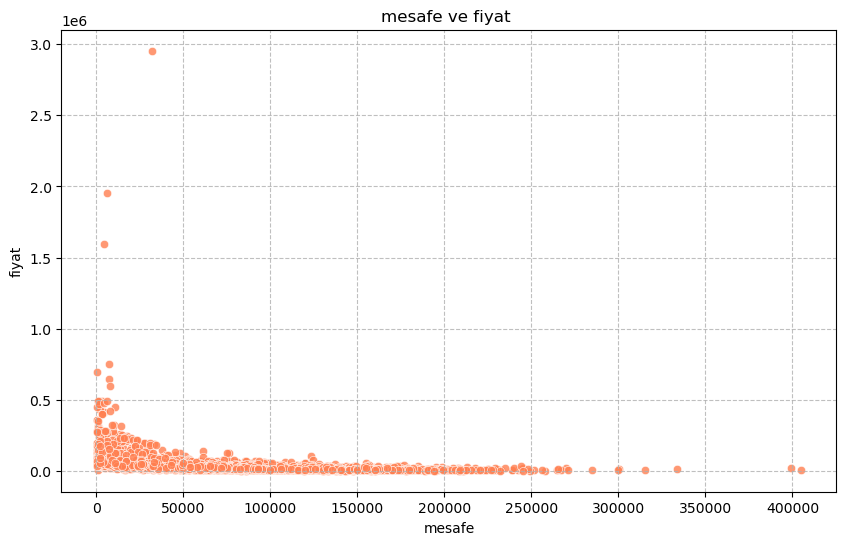

In [75]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='milage',y='price',color='coral',alpha=0.8)
plt.title('mesafe ve fiyat ')
plt.xlabel('mesafe')
plt.ylabel('fiyat')
plt.grid(True,linestyle='--',alpha=0.8)
plt.show()

grafige baktigim mesafe artigi zaman arabanin fiyatinda ciidi sekilde dusmeler oldugunu goruyorum
verimizin cogunlu dusuk - orta arasi mesafe ve fiyat arasinda kumelenmistir 
her data oldugu gibi burada da uc degerlermiz vardir cok dusuk kilometreye 3 milyon dolara kadar olan arabalarda gozukmeketedir vermizde

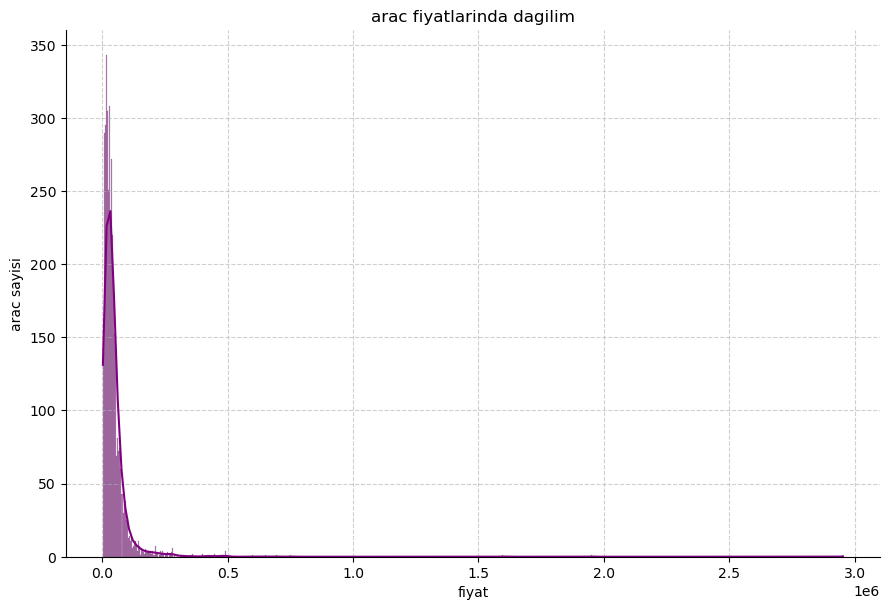

In [76]:
sns.displot(data=df,x='price',kde=True,color='purple',height=6,aspect=1.5)
plt.title('arac fiyatlarinda dagilim')
plt.xlabel('fiyat')
plt.ylabel('arac sayisi')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

fiyat dagilimina baktigim zaman saga carpik oldugunu goruyorum araclarin bircogu orta az tarafta yer almaktadair ve yukarida grafikte gordugumuz aykiri degerler burada da uzun bir kuyruk olusturmustur bize

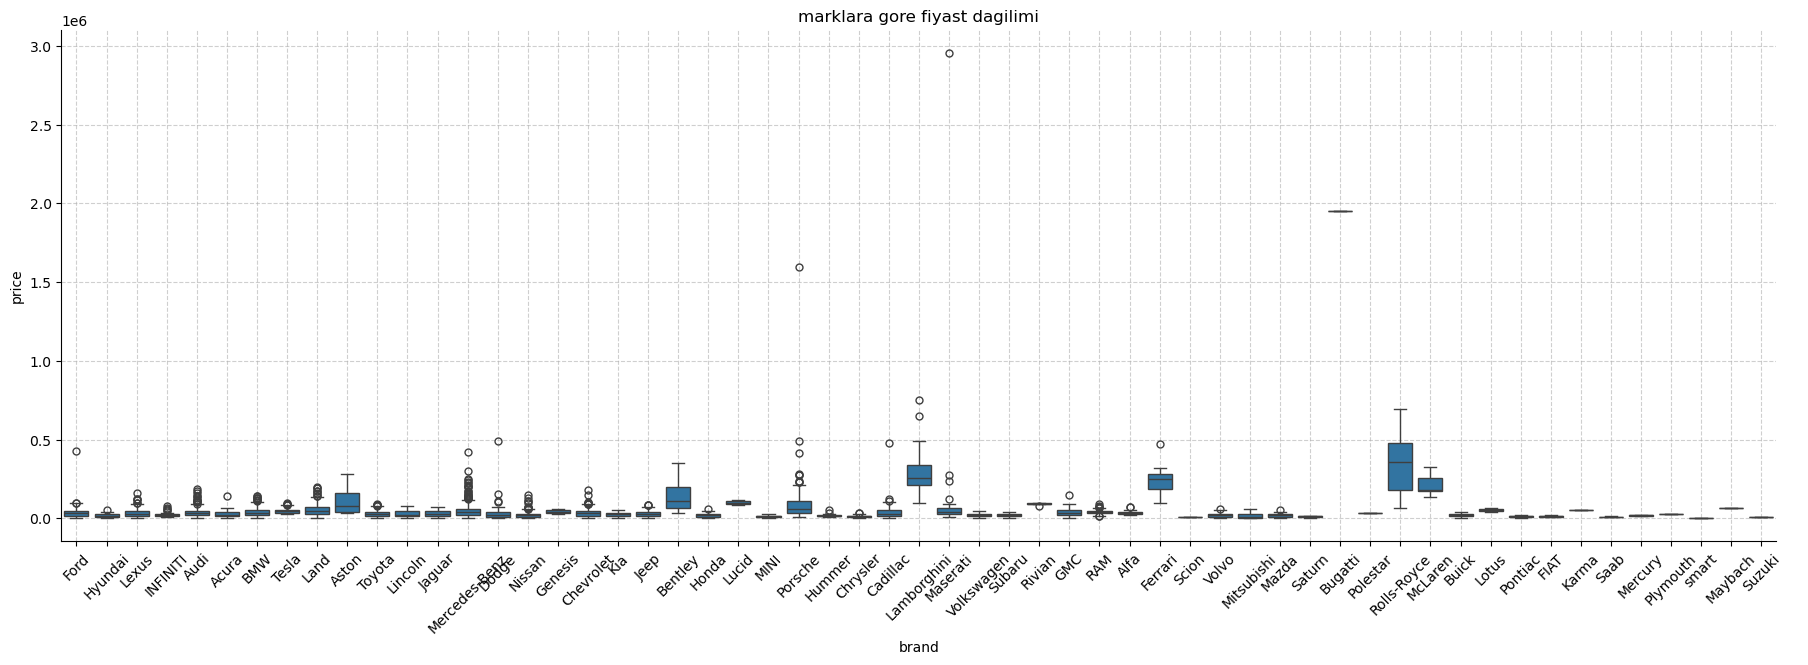

In [77]:
sns.catplot(data=df,x='brand',y='price',kind='box',height=6,aspect=3)
plt.title('marklara gore fiyast dagilimi')
plt.xticks(rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

aslinda guzel bir grafik odu ama cok karmasik oldu bundan dolayi en cok aranan markalar olarak guncelliyecem tablomu

C:\Users\PC\AppData\Local\Temp\ipykernel_12608\173940326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df_filtered, x='brand', y='price', kind='box', height=7, aspect=2, palette='Set2')


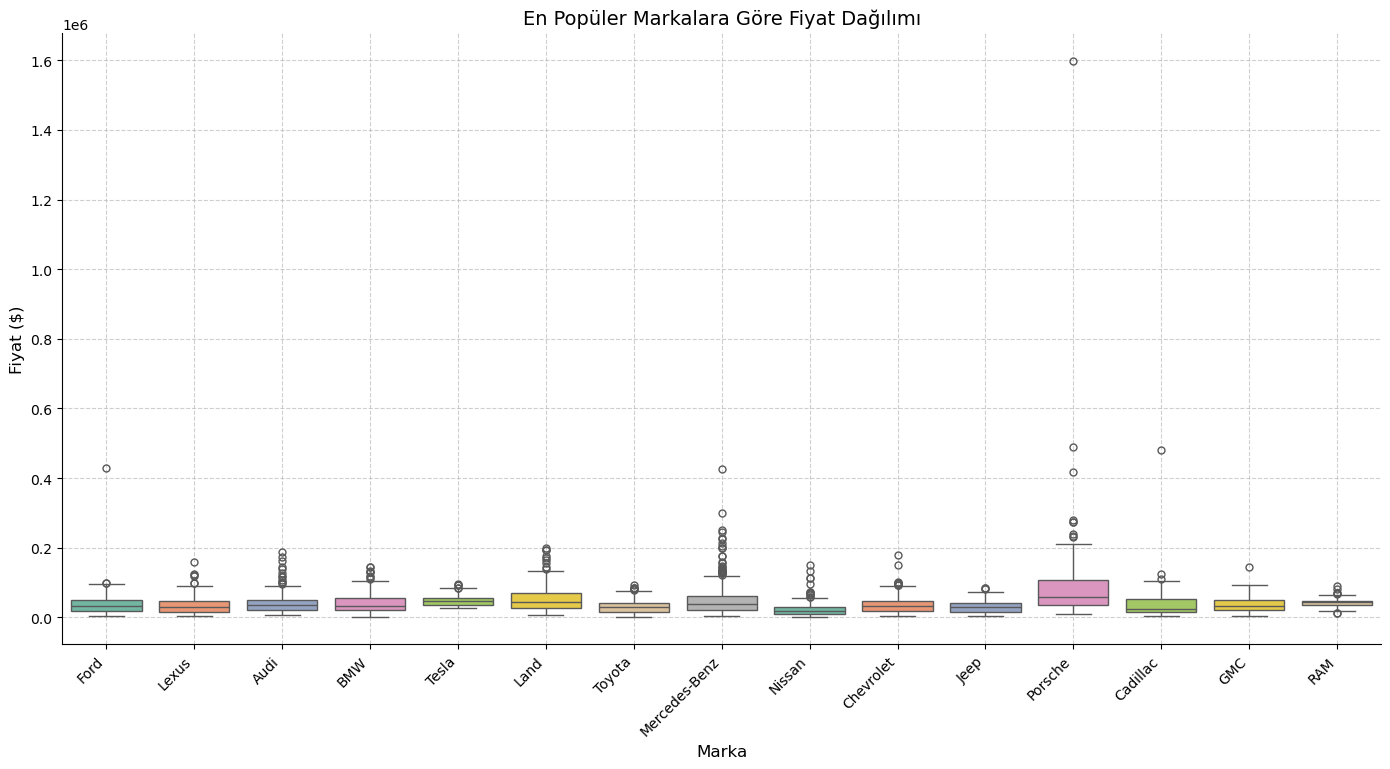

In [78]:
top_brands = df['brand'].value_counts().head(15).index
df_filtered = df[df['brand'].isin(top_brands)]

sns.catplot(data=df_filtered, x='brand', y='price', kind='box', height=7, aspect=2, palette='Set2')

plt.title('En Popüler Markalara Göre Fiyat Dağılımı', fontsize=14)
plt.xlabel('Marka', fontsize=12)
plt.ylabel('Fiyat ($)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

grafigime baktigim zaman populer marklarin buyuk bir cogunlugun medyan cizgisinin ayni seviyede oldugunu goruyorum genelde grafikteki marklarin cogunlu orta az tarafta
aykiri deger bakimindan gozume en cok mercedes carpiyor bunun disinda da porche tarafinda da diger markalra goredaha genis bir kutu araligi ve daha yukarida bir medyan cizgisi vardir 

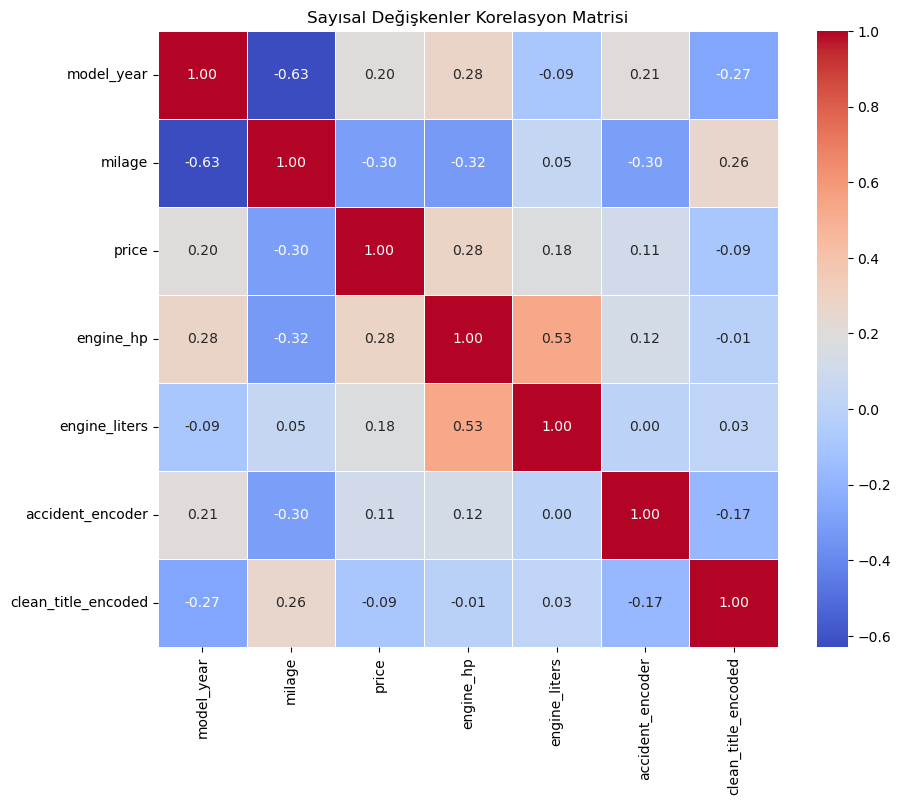

In [79]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Sayısal Değişkenler Korelasyon Matrisi')
plt.show()

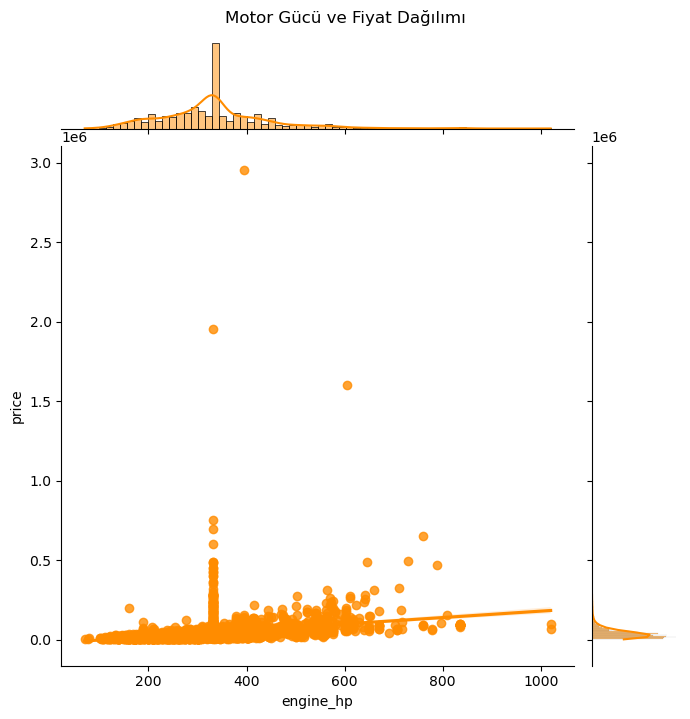

In [80]:
sns.jointplot(data=df.dropna(subset=['engine_hp']), x='engine_hp', y='price', kind='reg', color='darkorange', height=7)
plt.suptitle('Motor Gücü ve Fiyat Dağılımı', y=1.02)
plt.show()

arabinin gucu artikca fiyati da aartmaktadir en cok aykiri degeri 300 hp civarinda goruyorum histogram ve kde cizgisine baktimda bize ayni seyleri gosteriyor


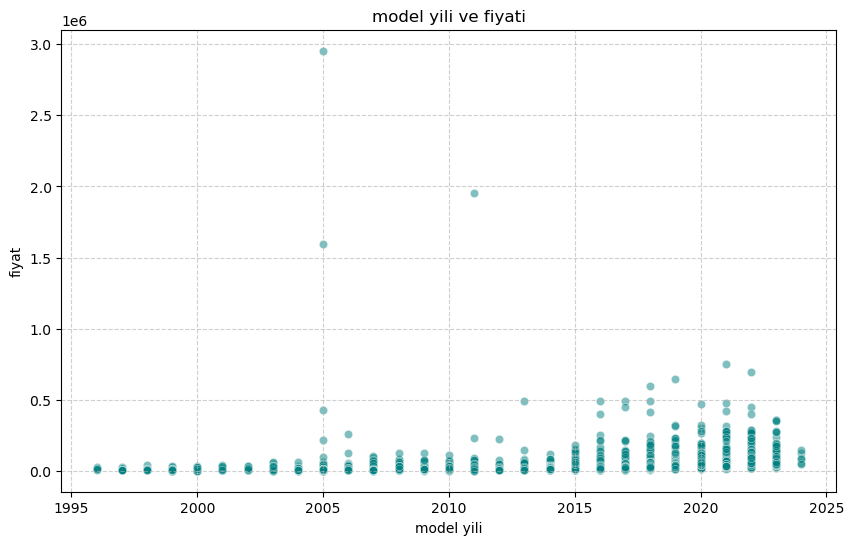

In [81]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='model_year',y='price',color='teal',alpha=0.5)
plt.title('model yili ve fiyati')
plt.xlabel('model yili')
plt.ylabel('fiyat')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

beklendigi gibi arabanin yada modelin uretim yili ne kadar yeniyse ortalam olarak fiyatlarda o kadar yukariya dogru cikiyor tabikide aykiri degerlermizde mevcut ama genel tablo icin bunu diyebiliriz 

FEATURE ENGINEERING

In [82]:
X = df.drop('price',axis=1)
y = df['price']

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=12)

In [85]:
corr_matrix = X_train.select_dtypes(include=['number', 'bool']).corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool) # tekari olemek icin ust ucgeni almayi tercih ettim
)

# 3. Korelasyonu %85'in (0.85) üzerinde olan sütunları bulalım
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print("Çıkarılacak yüksek korelasyonlu sütunlar:", to_drop)

# 4. Bu sütunları hem X_train'den hem de varsa X_test'ten düşürelim
X_train_cleaned = X_train.drop(columns=to_drop)
# X_test'ten de aynı yüksek korelasyonlu sütunları düşürelim
X_test_cleaned = X_test.drop(columns=to_drop, errors='ignore')

Çıkarılacak yüksek korelasyonlu sütunlar: ['transmission_clean_Manual']


one hot yaptigim ve bool olan kolanalrimi scale etmiyorum 

In [86]:
scaled_col = ['milage', 'engine_hp', 'engine_liters', 'model_year']

bu kolanlari scale edecegim ben

In [87]:
X_train_scaled = X_train_cleaned.copy()
X_test_scaled = X_test_cleaned.copy() # vermizi korumak icin buraya kopyaladim

In [88]:
from sklearn.preprocessing import StandardScaler

In [89]:
scaler = StandardScaler()

In [90]:
X_train_scaled[scaled_col] = scaler.fit_transform(X_train_cleaned[scaled_col])
X_test_scaled[scaled_col] = scaler.transform(X_test_cleaned[scaled_col])

In [91]:
from sklearn.linear_model import LinearRegression

In [92]:
regression = LinearRegression()

In [93]:
X_train_model = X_train_scaled.drop(['brand', 'model'], axis=1, errors='ignore')
X_test_model = X_test_scaled.drop(['brand', 'model'], axis=1, errors='ignore')

brand ve model kisimlari hala object oldu icin scale ettgim kisimdan onlari cikarttimve yeni esitlik olusturup boyle devam edecegim

In [94]:
regression.fit(X_train_model,y_train)

LinearRegression()

In [95]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X_train_model.columns,
    'Coefficient': regression.coef_
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print(coef_df)
print("\nIntercept (Sabit Terim):", regression.intercept_)

                         Feature   Coefficient
23            int_col_clean_blue  25750.591437
5               fuel_type_Hybrid  24744.904409
28             int_col_clean_tan  24202.156242
2               fuel_type_Diesel  17870.837383
4             fuel_type_Gasoline  17506.639469
29           int_col_clean_white  13104.398817
16           ext_col_clean_other  11685.769236
8                  engine_liters  11620.022885
20          ext_col_clean_yellow  10082.483749
26           int_col_clean_other   8000.204184
7                      engine_hp   7991.875846
30              accident_encoder   6833.067174
3        fuel_type_E85 Flex Fuel   6446.918199
12           ext_col_clean_brown   3126.344913
0                     model_year   3099.131319
31           clean_title_encoded    664.071334
14           ext_col_clean_green    322.047242
19           ext_col_clean_white    141.684740
13            ext_col_clean_gray   -261.918265
10           ext_col_clean_black  -1574.483893
17           

In [96]:
y_pred = regression.predict(X_test_model)

In [97]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [98]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)

mae 24823.838301343487
mse 9235901192.880465
r2 score 0.09358509919338232


In [99]:
from sklearn.preprocessing import PolynomialFeatures

In [100]:
poly = PolynomialFeatures(degree=2,include_bias=False)

In [101]:
X_train_poly = poly.fit_transform(X_train_model)
X_test_poly = poly.transform(X_test_model)

In [102]:
regression = LinearRegression()

In [103]:
regression.fit(X_train_poly,y_train)

LinearRegression()

In [104]:
y_pred_poly = regression.predict(X_test_poly)
r2_score(y_test,y_pred_poly)

-0.03161662328598469

In [105]:
y_test_pred_poly = regression.predict(X_test_poly)

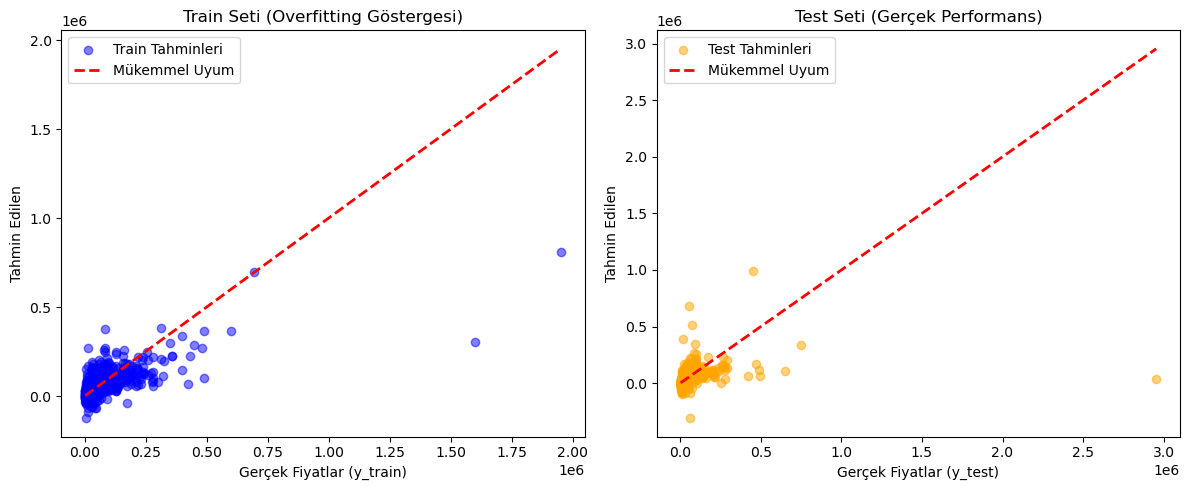

In [106]:
# Tahminleri garanti olması için tekrar hesaplayalım
y_train_pred = regression.predict(X_train_poly)
y_test_pred_poly = regression.predict(X_test_poly)

plt.figure(figsize=(12, 5))

# 1. Train Grafiği (Ezberlenen durum)
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', label='Train Tahminleri')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Mükemmel Uyum')
plt.xlabel('Gerçek Fiyatlar (y_train)')
plt.ylabel('Tahmin Edilen')
plt.title('Train Seti (Overfitting Göstergesi)')
plt.legend()

# 2. Test Grafiği (Gerçek başarı)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred_poly, alpha=0.5, color='orange', label='Test Tahminleri')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Mükemmel Uyum')
plt.xlabel('Gerçek Fiyatlar (y_test)')
plt.ylabel('Tahmin Edilen')
plt.title('Test Seti (Gerçek Performans)')
plt.legend()

plt.tight_layout()
plt.show()

Polinom Regresyon modeli, eksik özellikler ve yetersiz genelleme kapasitesi nedeniyle hem eğitim hem de test verilerinde yüksek hata payıyla başarısız olmuştur. Bu durum, doğrusal olmayan karmaşık ilişkileri yakalamak için daha gelişmiş ağaç tabanlı modellere geçilmesi gerektiğini açıkça ortaya koymaktadır

MULTUCOLLINERATIY

LINEARREGRESSION MODEL

mae 24823.838301343487
mse 9235901192.880465
r2 score 0.09358509919338232


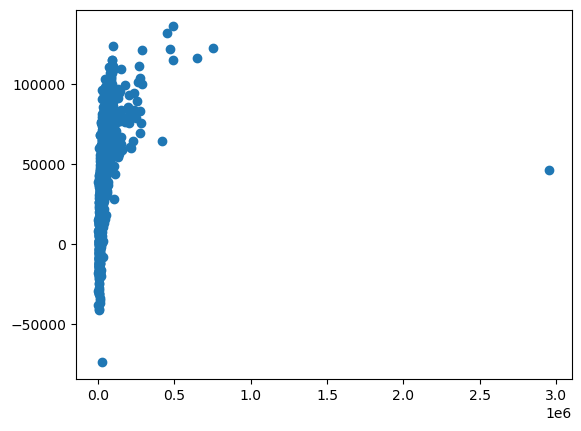

In [107]:
linear = LinearRegression()
linear.fit(X_train_model,y_train)
y_pred = linear.predict(X_test_model)
mae - mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

LASSO

In [108]:
from sklearn.linear_model import Lasso

mae 24823.838301343487
mse 9235562124.666853
r2 score 0.09361837547847784


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.586e+09, tolerance: 1.244e+09
  model = cd_fast.enet_coordinate_descent(


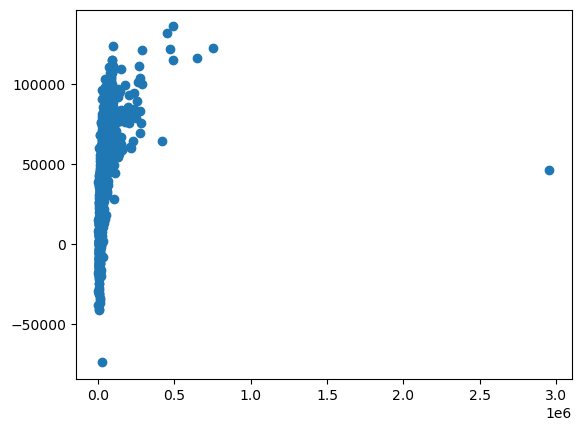

In [109]:
lasso = Lasso()
lasso.fit(X_train_model,y_train)
y_pred = lasso.predict(X_test_model)
mae - mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

RIDGE

In [110]:
from sklearn.linear_model import Ridge

mae 24823.838301343487
mse 9234237403.776579
r2 score 0.09374838409694164


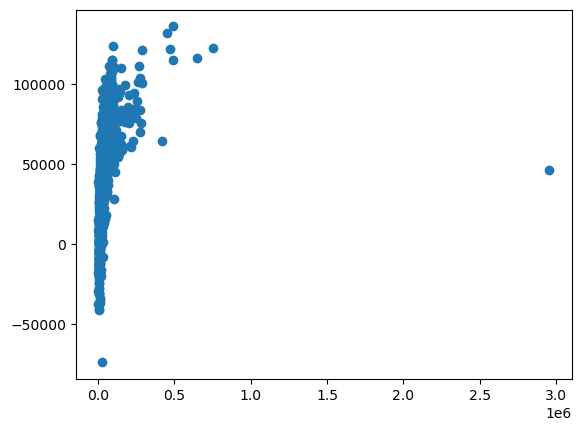

In [111]:
ridge = Ridge()
ridge.fit(X_train_model,y_train)
y_pred = ridge.predict(X_test_model)
mae - mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

ELASTICNET

In [112]:
from sklearn.linear_model import ElasticNet

mae 24823.838301343487
mse 9300209859.08579
r2 score 0.0872738219198187


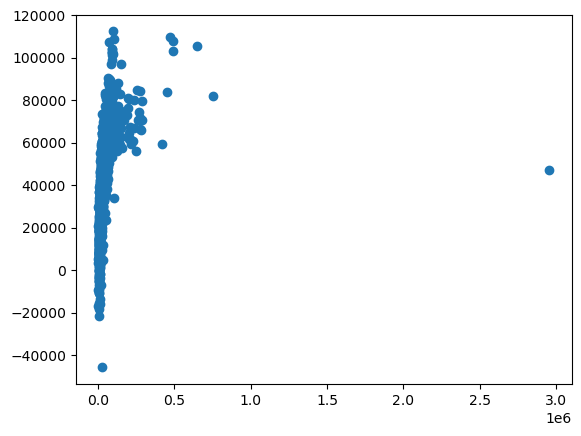

In [113]:
elastic = ElasticNet()
elastic.fit(X_train_model,y_train)
y_pred = elastic.predict(X_test_model)
mae - mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

LASSOCV

In [114]:
from sklearn.linear_model import LassoCV

mae 24823.838301343487
mse 9201978623.122097
r2 score 0.09691427325669277


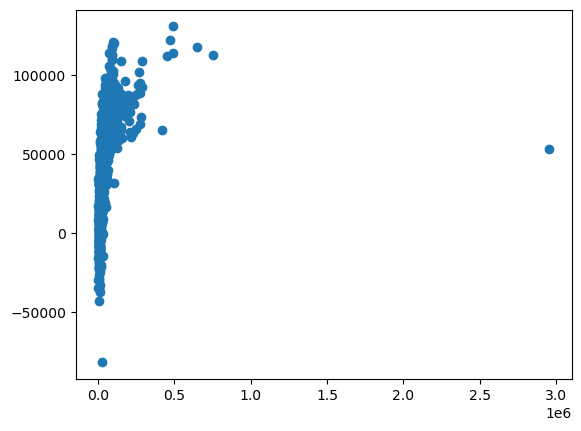

In [115]:
lassocv = LassoCV()
lassocv.fit(X_train_model,y_train)
y_pred = lassocv.predict(X_test_model)
mae - mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

RIDGECV

In [116]:
from sklearn.linear_model import RidgeCV

mae 24823.838301343487
mse 9226098260.754347
r2 score 0.09454716272840136


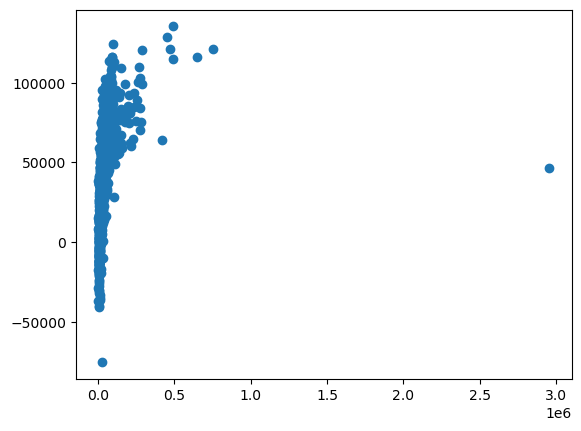

In [117]:
ridgecv = RidgeCV()
ridgecv.fit(X_train_model,y_train)
y_pred = ridgecv.predict(X_test_model)
mae - mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

ELASTICNETCV

In [118]:
from sklearn.linear_model import ElasticNetCV

mae 24823.838301343487
mse 10070216494.630249
r2 score 0.01170507409524435


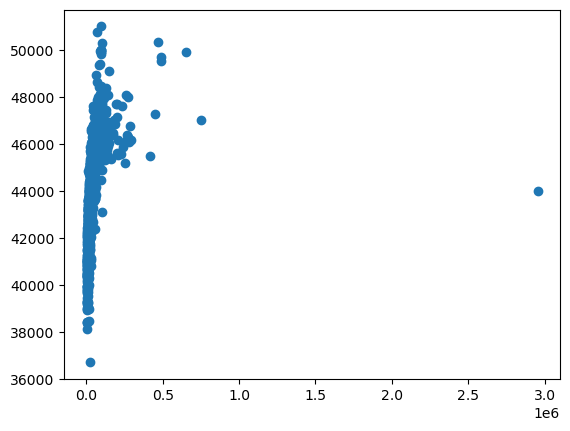

In [119]:
elasticnetcv = ElasticNetCV()
elasticnetcv.fit(X_train_model,y_train)
y_pred = elasticnetcv.predict(X_test_model)
mae - mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

Lineer modellerin bu veri setindeki karmaşık ve doğrusal olmayan ilişkileri yakalamakta yetersiz kalacağını öngörmüştük. Ancak projede adım adım ilerleyişimizi göstermek ve tüm varsayımları test etmek adına bu modelleri detaylıca uyguladık. Görüldüğü üzere skorlar düşük kaldı ve overfitting gözlemlendi. Bir sonraki aşamada çok daha güçlü modellerle devam edeceğiz

LOGISTIC REGRESSION

logistic regression bir siniflandirma algoritmasidir ve biz fiyyat tahmin etmeye yonelik gittgimiz icin logistik burada patlar bundan dolayi fiyatlari araliklara blucem ve logistic uygulayacam bu sayede burayida gormus oluruz

siniflari medyana gore 2 ye ayiracam

In [120]:
median_price = y_train.median()

y_train_class = (y_train > median_price).astype(int)
y_test_class = (y_test > median_price).astype(int)

print(f"Sınıflandırma Eşik Değeri : {median_price}")
print(f"Eğitim setindeki sınıf dağılımı:\n{y_train_class.value_counts()}")

Sınıflandırma Eşik Değeri : 31750.0
Eğitim setindeki sınıf dağılımı:
price
0    1376
1    1375
Name: count, dtype: int64


In [121]:
from sklearn.linear_model import LogisticRegression

In [122]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [123]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_model, y_train_class)

# Tahmin yap
y_pred_class = log_reg.predict(X_test_model)

# Başarı metrikleri
print("Accuracy (Doğruluk Oranı):", accuracy_score(y_test_class, y_pred_class))
print("\nSınıflandırma Raporu:\n", classification_report(y_test_class, y_pred_class))

Accuracy (Doğruluk Oranı): 0.8804071246819338

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       607
           1       0.88      0.88      0.88       572

    accuracy                           0.88      1179
   macro avg       0.88      0.88      0.88      1179
weighted avg       0.88      0.88      0.88      1179



2 ye ayirdiktan sonra 88 gibi yuksek bir score elde ettik buda modelin pahali mi ucuz mu seklinde ayirt edebildigini ama fiyati tahmin etmeye gelince zorlandigini goruyoruz

HYPARAMETER TUNING 

In [124]:
model= LogisticRegression()

In [125]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
}

In [126]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [127]:
cv = StratifiedKFold()

In [128]:
grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=cv,scoring='accuracy',n_jobs=-1)

In [129]:
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [130]:
grid.fit(X_train_model, y_train_class)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [131]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}

In [132]:
grid.best_score_

np.float64(0.8822299950503218)

In [133]:
y_pred = grid.predict(X_test_model)

In [134]:
print(accuracy_score(y_test_class,y_pred))
print(confusion_matrix(y_test_class,y_pred))
print(classification_report(y_test_class,y_pred))

0.8787107718405428
[[533  74]
 [ 69 503]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       607
           1       0.87      0.88      0.88       572

    accuracy                           0.88      1179
   macro avg       0.88      0.88      0.88      1179
weighted avg       0.88      0.88      0.88      1179



zaten cok fazla bir sey degismedi icin hyperparameter tuninbg yaptigimizda ayni sonucu aldik beklenen bir durumdu 

In [135]:
from sklearn.model_selection import RandomizedSearchCV

In [136]:
model = LogisticRegression(max_iter=5000)
randomcv = RandomizedSearchCV(estimator=model,param_distributions=param_grid,cv=cv,n_iter=10,scoring='accuracy',n_jobs=-1)

In [137]:
randomcv.fit(X_train_model,y_train_class)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=LogisticRegression(max_iter=5000), n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   scoring='accuracy')

In [138]:
randomcv.best_params_

{'solver': 'saga', 'penalty': 'l1', 'C': 0.1}

In [139]:
randomcv.best_score_

np.float64(0.8822299950503218)

In [140]:
y_pred = randomcv.predict(X_test_model)

In [141]:
print(accuracy_score(y_test_class,y_pred))
print(confusion_matrix(y_test_class,y_pred))
print(classification_report(y_test_class,y_pred))

0.8787107718405428
[[533  74]
 [ 69 503]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       607
           1       0.87      0.88      0.88       572

    accuracy                           0.88      1179
   macro avg       0.88      0.88      0.88      1179
weighted avg       0.88      0.88      0.88      1179



ROC_AUC_SCORE --- ROC_CURVE

In [142]:
model_prob = grid.predict_proba(X_test_model)
model_prob

array([[0.79468353, 0.20531647],
       [0.84967013, 0.15032987],
       [0.05538787, 0.94461213],
       ...,
       [0.99846395, 0.00153605],
       [0.74794254, 0.25205746],
       [0.19327848, 0.80672152]])

In [143]:
model_prob = model_prob[:,1] # sadece pozitifleri gormek icin boyle bir sey yaptim

In [144]:
from sklearn.metrics import roc_auc_score,roc_curve

In [145]:
model_suc = roc_auc_score(y_test_class,model_prob)

In [146]:
model_suc

np.float64(0.945467218119607)

In [147]:
model_fpr,model_tpr,threshould = roc_curve(y_test_class,model_prob)

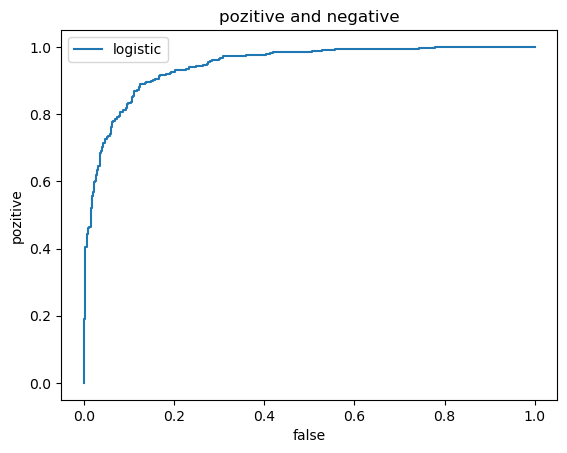

In [148]:
plt.plot(model_fpr,model_tpr,marker=',',label='logistic')
plt.xlabel('false')
plt.ylabel('pozitive')
plt.title('pozitive and negative')
plt.legend()
plt.show()

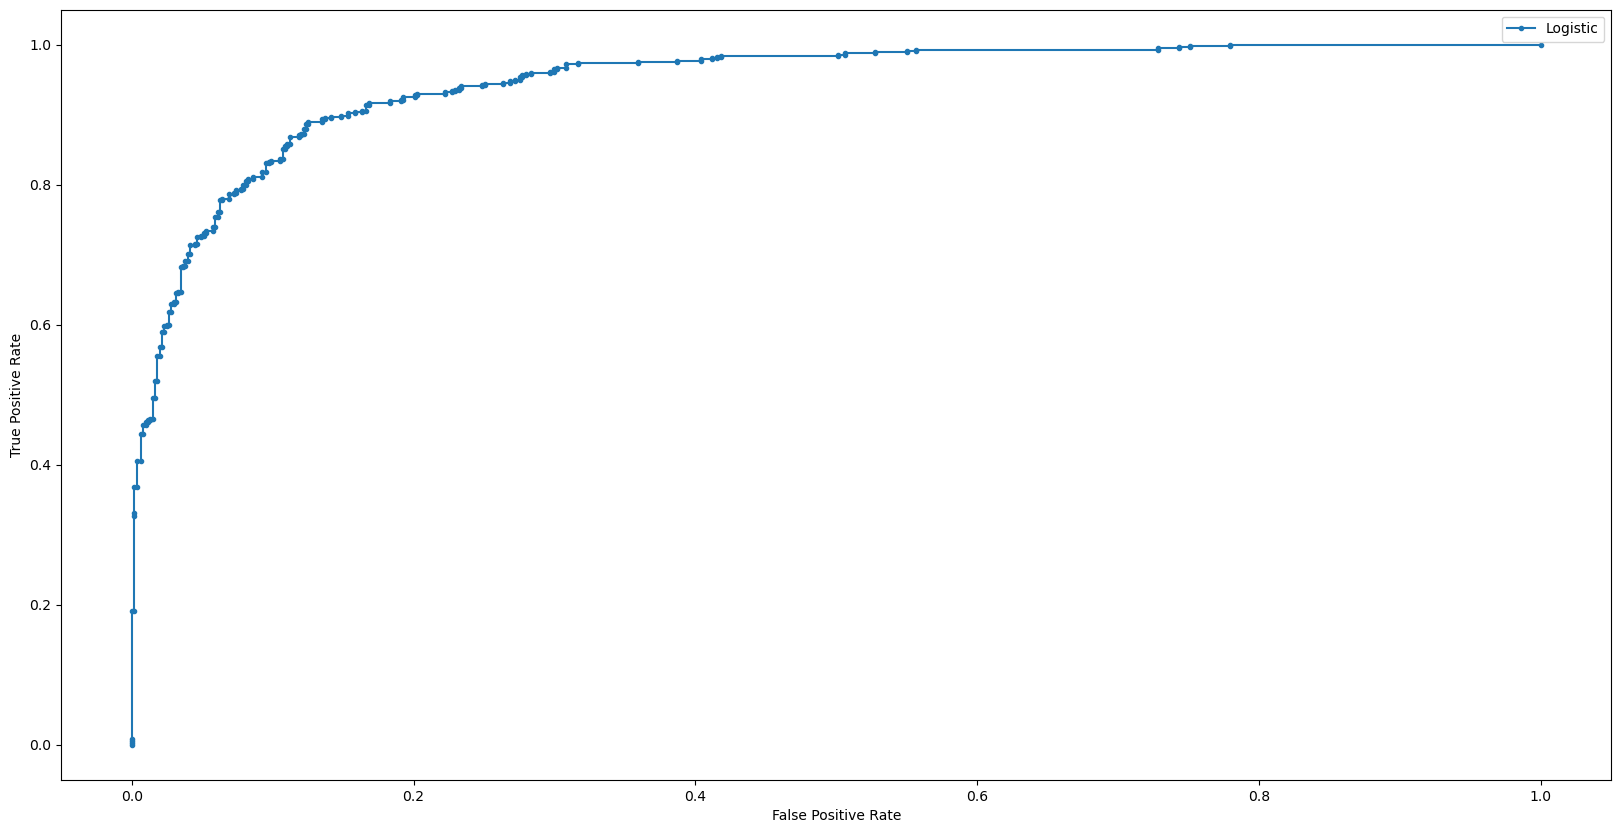

In [149]:
fig, ax = plt.subplots(figsize = (20,10))

ax.plot(model_fpr, model_tpr, marker = ".", label = "Logistic")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

grafige baktigim zaman modelimi aciklamada gayet iyi oldugunu goruyorum cunku mavi cizgi sol ust koseye baya bir yakin konumda grafigimizde AUC kismida gayet basari cunku mavi cizginin altina kalan kisimda neredeyse grafigimiz kadar 

SVR

modelim svr tercih ettim cunku scv 0 ve 1 lerden olusan datalar icin cok iyidir bizim bu datadaki amacimiz surekli bir sayisal degeri tahmin etmek oldugu icin SVR  bizim icin mantikli secenek oluyor burada

In [150]:
from sklearn.svm import SVR

In [151]:
svr = SVR()

In [152]:
svr.fit(X_train_model,y_train)

SVR()

In [153]:
y_pred_svr =svr.predict(X_test_model)

In [154]:
# 1. Doğru tahmin değişkenini kullanıyoruz: y_pred_svr
score = r2_score(y_test, y_pred_svr)
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", score)

MAE: 28185.734540866993
MSE: 10381505729.87721
RMSE: 101889.6743045006
R2 Score: -0.018844971362804053


SVR DA ıyı bır sonuc alamadım yapay zekadan yardım aldım onunla beraber onerdıgı seylerı yapıcam ve daha ıyı bır sonuc almaya calısamcam svr de


In [155]:
scaler_y_svr = StandardScaler()
y_train_svr_scaled = scaler_y_svr.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_svr_scaled = scaler_y_svr.transform(y_test.values.reshape(-1, 1)).ravel()

In [156]:
svr_model = SVR(kernel='rbf', C=1000.0, epsilon=0.1)

In [157]:
svr_model.fit(X_train_model, y_train_svr_scaled)

SVR(C=1000.0)

In [158]:
y_pred_svr_scaled = svr_model.predict(X_test_model)

In [159]:
y_pred_svr = scaler_y_svr.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

In [160]:
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred_svr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", score)

MAE: 28621.092114106705
MSE: 10095435085.537022
RMSE: 100476.04234610866
R2 Score: 0.009230111869266366


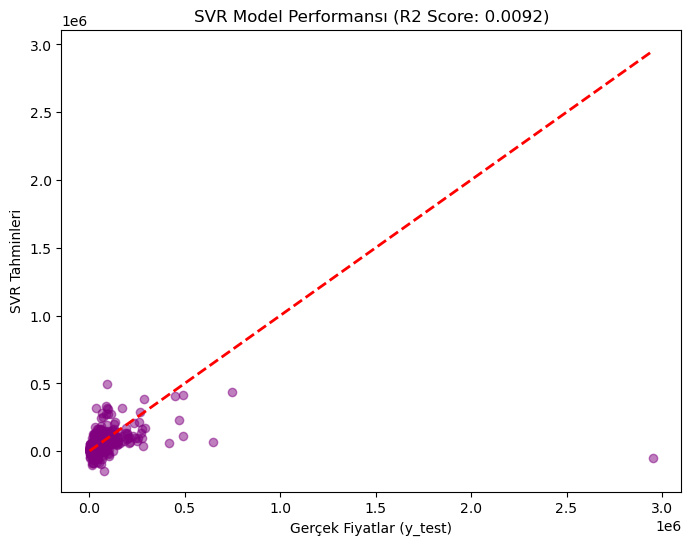

In [161]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.5, color='purple')
plt.xlabel("Gerçek Fiyatlar (y_test)")
plt.ylabel("SVR Tahminleri")
plt.title(f"SVR Model Performansı (R2 Score: {score:.4f})")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

Doğrusal modeller ve SVR, araba fiyatları veri setindeki doğrusal olmayan karmaşık ilişkileri ve uç değerleri modellemekte yetersiz kalmıştır. Bu nedenle elde edilen düşük skorlar, doğrusal yaklaşımların bu problem için sınırda kaldığını açıkça göstermektedir. Projenin bir sonraki aşamasında, verideki bu karmaşıklığı çok daha başarılı bir şekilde yönetebilen ağaç tabanlı (Random Forest, XGBoost, LightGBM) gelişmiş algoritmalara geçilecektir

In [162]:
from sklearn.model_selection import GridSearchCV

In [163]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

In [164]:
scaler_X_svr = StandardScaler()
X_train_svr_scaled = scaler_X_svr.fit_transform(X_train_model)
X_test_svr_scaled = scaler_X_svr.transform(X_test_model)

grid = GridSearchCV(estimator=SVR(),param_grid=param_grid,cv=5,n_jobs=-1)
grid.fit(X_train_svr_scaled,y_train_svr_scaled)

yukaridaki kisimi pc de calistiramadim belkide hata yapiyorum aam gende svr kismindan zaten cok bir bekletim yoktu bundan dolayi burayi sonlandiriyorum daha iyi sonuclar almak icin baska yontemler deniyecem

Gaussian sureli sayisal ozellikleri normal dagilma sahip oldugu varsayimiyla verilerin hangi sinifa ait oldugunu olasiliksal olarak hesaplayan bir siniflandirmadir benim verim benim pc icinde cok buyuk ve bu dataya cokta uymadigi icin onuda yapmiyacam projeme

KNN mantikszi oldugu icin onuda yapmiyacam verimde

In [165]:
from sklearn.tree import DecisionTreeRegressor

In [166]:
tree = DecisionTreeRegressor(max_depth=15, random_state=15)

In [167]:
tree.fit(X_train_model,y_train)

DecisionTreeRegressor(max_depth=15, random_state=15)

In [168]:
y_pred  = tree.predict(X_test_model)

In [169]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", score)

MAE: 22046.563942652592
MSE: 13015019668.99179
RMSE: 114083.38910197133
R2 Score: -0.2772990437965217


decision tree zaten tekli bir agac boyutudur vermizde cok ise yaramayacagini biliyordum sadece denemek ve gostermek istedim

ENSEBLE

RANDOM FOREST

In [170]:
from sklearn.ensemble import RandomForestRegressor

In [171]:
rfc = RandomForestRegressor(n_estimators=100,max_depth=20,random_state=15)
rfc.fit(X_train_model,y_train)

RandomForestRegressor(max_depth=20, random_state=15)

In [172]:
y_pred = rfc.predict(X_test_model)

In [173]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

16146.94363675994
8631425567.543457
0.15290856991242996


In [174]:
rfc = RandomForestRegressor(n_estimators=1000,max_depth=20,random_state=15)
rfc.fit(X_train_model,y_train)
y_pred = rfc.predict(X_test_model)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

16054.189982370932
8584737832.007102
0.15749052226242832


r2 scorumuz eksiden artiya dondu ama hala yeterli bir seviyede degil bunu daha iyi noktalara getirmeye calisacagim

In [175]:
rfc.feature_importances_

array([1.57548238e-01, 2.81229652e-01, 1.42791754e-03, 5.67340112e-05,
       1.41600133e-03, 7.91270009e-04, 1.16448747e-06, 1.08593438e-01,
       2.86071166e-01, 6.79378076e-03, 4.42316022e-03, 3.61465605e-03,
       2.88084176e-04, 1.73918811e-02, 1.27659953e-03, 2.59426118e-04,
       3.46551632e-03, 2.99130916e-03, 4.79539527e-03, 2.42526685e-02,
       1.32929586e-03, 4.30953272e-03, 1.21125076e-02, 2.32727315e-03,
       8.51049309e-04, 1.41627610e-03, 3.90956582e-02, 1.94186708e-03,
       8.45429365e-04, 2.21844980e-02, 2.21686121e-03, 4.68169174e-03])

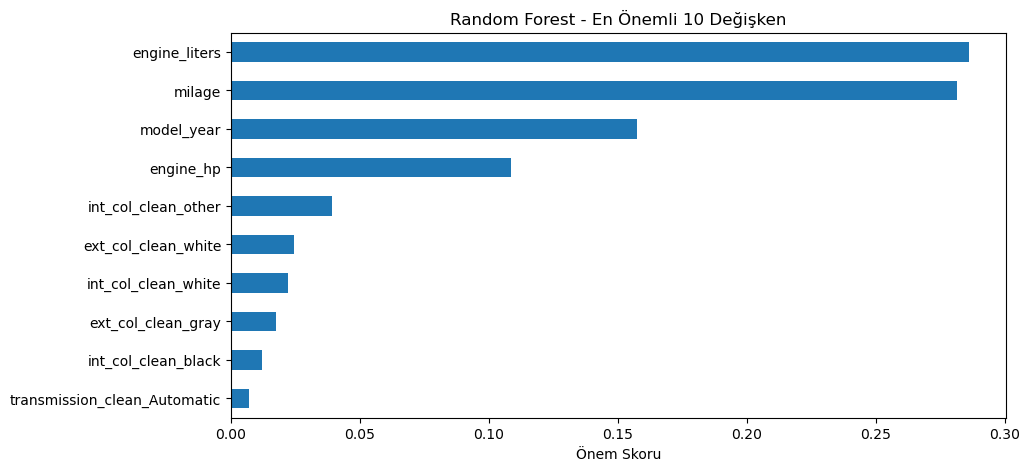

In [176]:
importances = pd.Series(rfc.feature_importances_, index=X_train_model.columns)
plt.figure(figsize=(10, 5))
importances.nlargest(10).plot(kind='barh')
plt.title('Random Forest - En Önemli 10 Değişken')
plt.xlabel('Önem Skoru')
plt.gca().invert_yaxis() # En yüksek olanı en üste getirmek için
plt.show()

ADABOOST 

In [177]:
from sklearn.ensemble import AdaBoostRegressor

In [178]:
ads = AdaBoostRegressor()
ads.fit(X_train_model,y_train)
y_pred = ads.predict(X_test_model)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

64578.441190404985
12668765073.078182
-0.24331748437373335


HYPERPARAMETER TUNING

In [179]:
adaboost_param = {
    'n_estimators':[50,70,120,150,200],
    'learning_rate': [0.001,0.01,0.1,1,10]
}

In [180]:
grid = GridSearchCV(estimator=AdaBoostRegressor(),param_grid=adaboost_param,cv=3,verbose=1,n_jobs=-1)

In [181]:
grid.fit(X_train_model,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


GridSearchCV(cv=3, estimator=AdaBoostRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10],
                         'n_estimators': [50, 70, 120, 150, 200]},
             verbose=1)

In [182]:
grid.best_params_

{'learning_rate': 0.1, 'n_estimators': 120}

In [183]:
grid.best_score_

np.float64(0.3238587359287935)

In [184]:
ads = AdaBoostRegressor(learning_rate=0.1,n_estimators=120)

In [185]:
ads.fit(X_train_model,y_train)
y_pred = ads.predict(X_test_model)

In [186]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

26927.89305001763
9146066814.285307
0.10240147971357705


AdaBoost ile yapılan hiperparametre optimizasyonuna rağmen, veri setinin yüksek boyutlu ve seyrek yapısı nedeniyle model test verisinde istenen genelleme başarısını gösterememiştir. Bu doğrultuda, tahmin performansını artırmak amacıyla gradient boosting tabanlı alternatif modellere geçilmesi kararlaştırılmıştır

GRADIENT BOOSTING

In [187]:
from sklearn.ensemble import GradientBoostingRegressor

In [188]:
grad = GradientBoostingRegressor(n_estimators=100,max_depth=3,learning_rate=0.1)

In [189]:
grad.fit(X_train_model,y_train)

GradientBoostingRegressor()

In [190]:
y_pred = grad.predict(X_test_model)

In [191]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

18326.47818195489
9204581435.691008
0.09665883222855742


HYPERPARAMATER TUNING

In [192]:
params = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'loss': ['squared_error', 'absolute_error', 'huber'],  # Regresyon kayıp fonksiyonları
    'learning_rate': [0.01, 0.1, 0.5]
}

In [193]:
random_grad = RandomizedSearchCV(estimator=GradientBoostingRegressor(),param_distributions=params,cv=5)

In [194]:
random_grad.fit(X_train_model,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber'],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 150, 200]})

In [195]:
random_grad.best_params_

{'n_estimators': 200,
 'max_depth': 5,
 'loss': 'absolute_error',
 'learning_rate': 0.1}

In [196]:
random_grad.best_score_

np.float64(0.4333264042463674)

In [197]:
grad = GradientBoostingRegressor(n_estimators=150,max_depth=4,loss='absolute_error',learning_rate=0.5)

In [198]:
grad.fit(X_train_model,y_train)

GradientBoostingRegressor(learning_rate=0.5, loss='absolute_error', max_depth=4,
                          n_estimators=150)

In [199]:
y_pred = grad.predict(X_test_model)

In [200]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

16973.642300348605
9322967844.022577
0.08504034451157849


Best score'da 0.41 seviyelerine kadar çıktık ancak genel olarak hedeflediğimiz performansın altındayız. Zaten bu tarz yüksek boyutlu ve karmaşık veri setlerinde AdaBoost'un yapısal olarak yetersiz kalması beklenen bir durumdu çünkü AdaBoost daha çok daha basit ve düşük boyutlu senaryolarda etkilidir

XGBOOST

In [201]:
from xgboost import XGBRegressor

In [202]:
xgb = XGBRegressor()
xgb.fit(X_train_model,y_train)
y_pred = xgb.predict(X_test_model)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

16397.347770969172
8963066842.95018
0.12036116739334646


HYPERPARAMETER TUNING

In [203]:
params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'colsample_bytree': [0.6, 0.8],
}

In [204]:
grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),param_grid=params,cv=3,  scoring='r2',verbose=1,n_jobs=-1,)

In [205]:
grid.fit(X_train_model,y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [206]:
grid.best_params_

{'colsample_bytree': 0.6,
 'learning_rate': 0.1,
 'max_depth': 7,
 'n_estimators': 200}

In [207]:
grid.best_score_

np.float64(0.4562009043402308)

aldigim sonuclardan memnun degilim bundan dolayida yapay zekadan yardim alacagim

Gemini Yapay Zeka

In [208]:
best_xgb = grid.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_model)
print("XGBoost Test R2 Score:", r2_score(y_test, y_pred_best_xgb))

XGBoost Test R2 Score: 0.13853991110753638


In [209]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Daha sıkı regülarizasyon ve kontrol parametreleri
params_xgb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 4, 5],             # Derinliği kontrollü tutuyoruz
    'subsample': [0.7, 0.8],            # Gözlem örneklemesi
    'colsample_bytree': [0.7, 0.8],     # Sütun örneklemesi (154 sütun için kritik)
    'reg_alpha': [0.1, 1, 2],           # L1 cezası (gürültülü özellikleri elemek için)
    'reg_lambda': [1, 2, 5]             # L2 cezası (aşırı öğrenmeyi önlemek için)
}

random_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=params_xgb,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train_model, y_train)

# Sonuçları kontrol edelim
print("En İyi Parametreler:", random_xgb.best_params_)
print("En İyi CV Skoru:", random_xgb.best_score_)

best_model_xgb = random_xgb.best_estimator_
y_pred_final = best_model_xgb.predict(X_test_model)
print("Yeni Test R2 Skoru:", r2_score(y_test, y_pred_final))

En İyi Parametreler: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
En İyi CV Skoru: 0.47541129692738676
Yeni Test R2 Skoru: 0.1785929481505063


Yapay zekada nerdenyse benle ayni soculari verdi bu data icin son olarak LightGBM  debiyecem sonrasina bakicaz

In [210]:
import lightgbm as lgb

In [211]:
clf = lgb.LGBMRegressor(n_jobs=-1)

In [212]:
clf.fit(X_train_model,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 2751, number of used features: 30
[LightGBM] [Info] Start training from score 44111.931298


LGBMRegressor(n_jobs=-1)

In [213]:
y_pred = clf.predict(X_test_model)

In [214]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

16806.138795312472
8251210689.878651
0.1902230044680321


YAPAY ZEKA

In [215]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Modeli logaritmik y ile eğit
clf.fit(X_train_model, y_train_log)

# Tahmin yap ve geri çevir (expm1)
y_pred_log = clf.predict(X_test_model)
y_pred = np.expm1(y_pred_log)

# Yeni skorları yazdır
print("Yeni R2 Score:", r2_score(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 2751, number of used features: 30
[LightGBM] [Info] Start training from score 10.308414
Yeni R2 Score: 0.17517708526732356


In [216]:
clf_tuned = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=63,  # Modelin kapasitesini artırıyoruz
    random_state=42,
    n_jobs=-1,
)

clf_tuned.fit(X_train_model, y_train_log)  # Log dönüşümlü y ile
y_pred_tuned = np.expm1(clf_tuned.predict(X_test_model))

print("Tuned LightGBM R2 Score:", r2_score(y_test, y_pred_tuned))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 2751, number of used features: 30
[LightGBM] [Info] Start training from score 10.308414
Tuned LightGBM R2 Score: 0.18139436199156667


In [217]:
# 1. Fiyatlara log dönüşümü yap (Büyük uçurumları törpüler)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. LightGBM'i logaritmik y ile eğit
lgb_model = lgb.LGBMRegressor(
    n_estimators=300, 
    learning_rate=0.03, 
    num_leaves=63, 
    random_state=42, 
    n_jobs=-1
)
lgb_model.fit(X_train_model, y_train_log)

# 3. Tahmin yap ve expm1 ile fiyatı eski haline geri çevir
y_pred_log = lgb_model.predict(X_test_model)
y_pred = np.expm1(y_pred_log)

# 4. Yeni skorları gör
print("Yeni MAE:", mean_absolute_error(y_test, y_pred))
print("Yeni MSE:", mean_squared_error(y_test, y_pred))
print("Yeni R2 Score:", r2_score(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 2751, number of used features: 30
[LightGBM] [Info] Start training from score 10.308414
Yeni MAE: 14367.131875897207
Yeni MSE: 8341170011.495429
Yeni R2 Score: 0.18139436199156667


In [218]:
import pandas as pd
import numpy as np

Q1 = y_train.quantile(0.01)
Q3 = y_train.quantile(0.99)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Filtrelemeden önceki train boyutu:", X_train_model.shape[0])

Filtrelemeden önceki train boyutu: 2751


In [219]:
# 1. Outlier'ları train setinden filtrele
mask = (y_train >= lower_bound) & (y_train <= upper_bound)
X_train_filtered = X_train_model[mask]
y_train_filtered = y_train[mask]

print("Filtrelenmiş yeni train boyutu:", X_train_filtered.shape[0])

# 2. Log dönüşümünü filtrelenmiş y üzerinde yap
y_train_filtered_log = np.log1p(y_train_filtered)

# 3. Modeli yeniden kur ve eğit
lgb_model_clean = lgb.LGBMRegressor(
    n_estimators=300, 
    learning_rate=0.03, 
    num_leaves=63, 
    random_state=42, 
    n_jobs=-1
)
lgb_model_clean.fit(X_train_filtered, y_train_filtered_log)

# 4. Test setinde tahmin yap ve skorları bas
y_pred_log_clean = lgb_model_clean.predict(X_test_model)
y_pred_clean = np.expm1(y_pred_log_clean)

print("Temizlenmiş Model Yeni MAE:", mean_absolute_error(y_test, y_pred_clean))
print("Temizlenmiş Model Yeni MSE:", mean_squared_error(y_test, y_pred_clean))
print("Temizlenmiş Model Yeni R2 Score:", r2_score(y_test, y_pred_clean))

Filtrelenmiş yeni train boyutu: 2748
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 586
[LightGBM] [Info] Number of data points in the train set: 2748, number of used features: 30
[LightGBM] [Info] Start training from score 10.304303
Temizlenmiş Model Yeni MAE: 14387.872995714088
Temizlenmiş Model Yeni MSE: 8439499858.593094
Temizlenmiş Model Yeni R2 Score: 0.17174423292001872


In [220]:
import pandas as pd

# Modelin en çok önem verdiği ilk 10 sütunu listeleyelim
importance_df = pd.DataFrame({
    'Feature': X_train_filtered.columns,
    'Importance': lgb_model_clean.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                         Feature  Importance
7                      engine_hp        4555
1                         milage        4345
8                  engine_liters        3718
0                     model_year        2759
22           int_col_clean_black         477
30              accident_encoder         287
10           ext_col_clean_black         280
9   transmission_clean_Automatic         272
4             fuel_type_Gasoline         178
2               fuel_type_Diesel         177


In [221]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 1. Özellikleri ölçeklendirelim
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_model)

# 2. Ridge Regresyon ile test edelim (Logaritmik y üzerinden)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_filtered_log)

ridge_pred_log = ridge.predict(X_test_scaled)
ridge_pred = np.expm1(ridge_pred_log)

print("Ridge Modeli R2 Score:", r2_score(y_test, ridge_pred))

Ridge Modeli R2 Score: 0.09774431016384955


In [222]:
print("X_train_filtered shape:", X_train_filtered.shape)
print("X_test_model shape:", X_test_model.shape)
print("y_train min-max:", y_train.min(), y_train.max())
print("y_test min-max:", y_test.min(), y_test.max())

X_train_filtered shape: (2748, 32)
X_test_model shape: (1179, 32)
y_train min-max: 2300.0 1950995.0
y_test min-max: 2000.0 2954083.0


In [223]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Eğer ana veri setin (X ve y) elindeyse, veriyi tekrar düzgün bölelim:
# (Burada X ve y tüm veri setini temsil ediyor, train_test_split'i yeniden çağırıyoruz)
X_train, X_test, y_train_new, y_test_new = train_test_split(X_train_filtered, y_train_filtered, test_size=0.2, random_state=42)

# Log dönüşümü
y_train_log = np.log1p(y_train_new)

# LightGBM modeli
model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=63, random_state=42)
model.fit(X_train, y_train_log)

# Tahmin ve skor
preds = np.expm1(model.predict(X_test))
print("Yepyeni R2 Score:", r2_score(y_test_new, preds))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 573
[LightGBM] [Info] Number of data points in the train set: 2198, number of used features: 28
[LightGBM] [Info] Start training from score 10.297867


C:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\PC\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Yepyeni R2 Score: 0.6770052832836052
